# Phase 0 Analysis Notebook

Visual inspection of the monotonicity experiment.

**Pre-reg:** `phase0/PHASE0_PREREG.md`
**Run:** `phase0/src/run_phase0.py`
**Outputs:** `phase0/outputs/`

Open this notebook AFTER running `run_phase0.py`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while ROOT.name and not (ROOT / 'phase0').exists():
    if ROOT.parent == ROOT:
        break
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('Project root:', ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUTPUTS = ROOT / 'phase0' / 'outputs'
traces = pd.read_csv(OUTPUTS / 'traces.csv')
mono = pd.read_csv(OUTPUTS / 'monotonicity.csv')
variants = pd.read_csv(OUTPUTS / 'variants_summary.csv')
variants_traces = pd.read_csv(OUTPUTS / 'variants_traces.csv')

print(f'traces.csv:    {len(traces)} rows ({traces.problem_id.nunique()} problems)')
print(f'monotonicity:  {len(mono)} rows')
print(f'variants:      {len(variants)} problems with sigma')

Project root: C:\Users\anshu\PycharmProjects\MonumentalLeapForward


traces.csv:    77 rows (20 problems)
monotonicity:  20 rows
variants:      20 problems with sigma


## 1. Headline summary

In [2]:
H = mono.composite_rate.mean()
H_strict = mono.composite_strict_rate.mean()
print(f'Headline composite (non-strict):  H = {H:.4f}')
print(f'Composite strict-decrease rate:    {H_strict:.4f}')
print()
print('Per-feature means:')
for f in ['depth_rate', 'ops_rate', 'leaves_rate', 'isolation_rate']:
    print(f'  {f:20s} {mono[f].mean():.4f}')

Headline composite (non-strict):  H = 0.6417
Composite strict-decrease rate:    0.5650

Per-feature means:
  depth_rate           0.8625
  ops_rate             0.8250
  leaves_rate          0.8167
  isolation_rate       0.8583


## 2. Per-problem composite trajectories

Each subplot shows composite φ at every step on a problem's trace. Color = category.

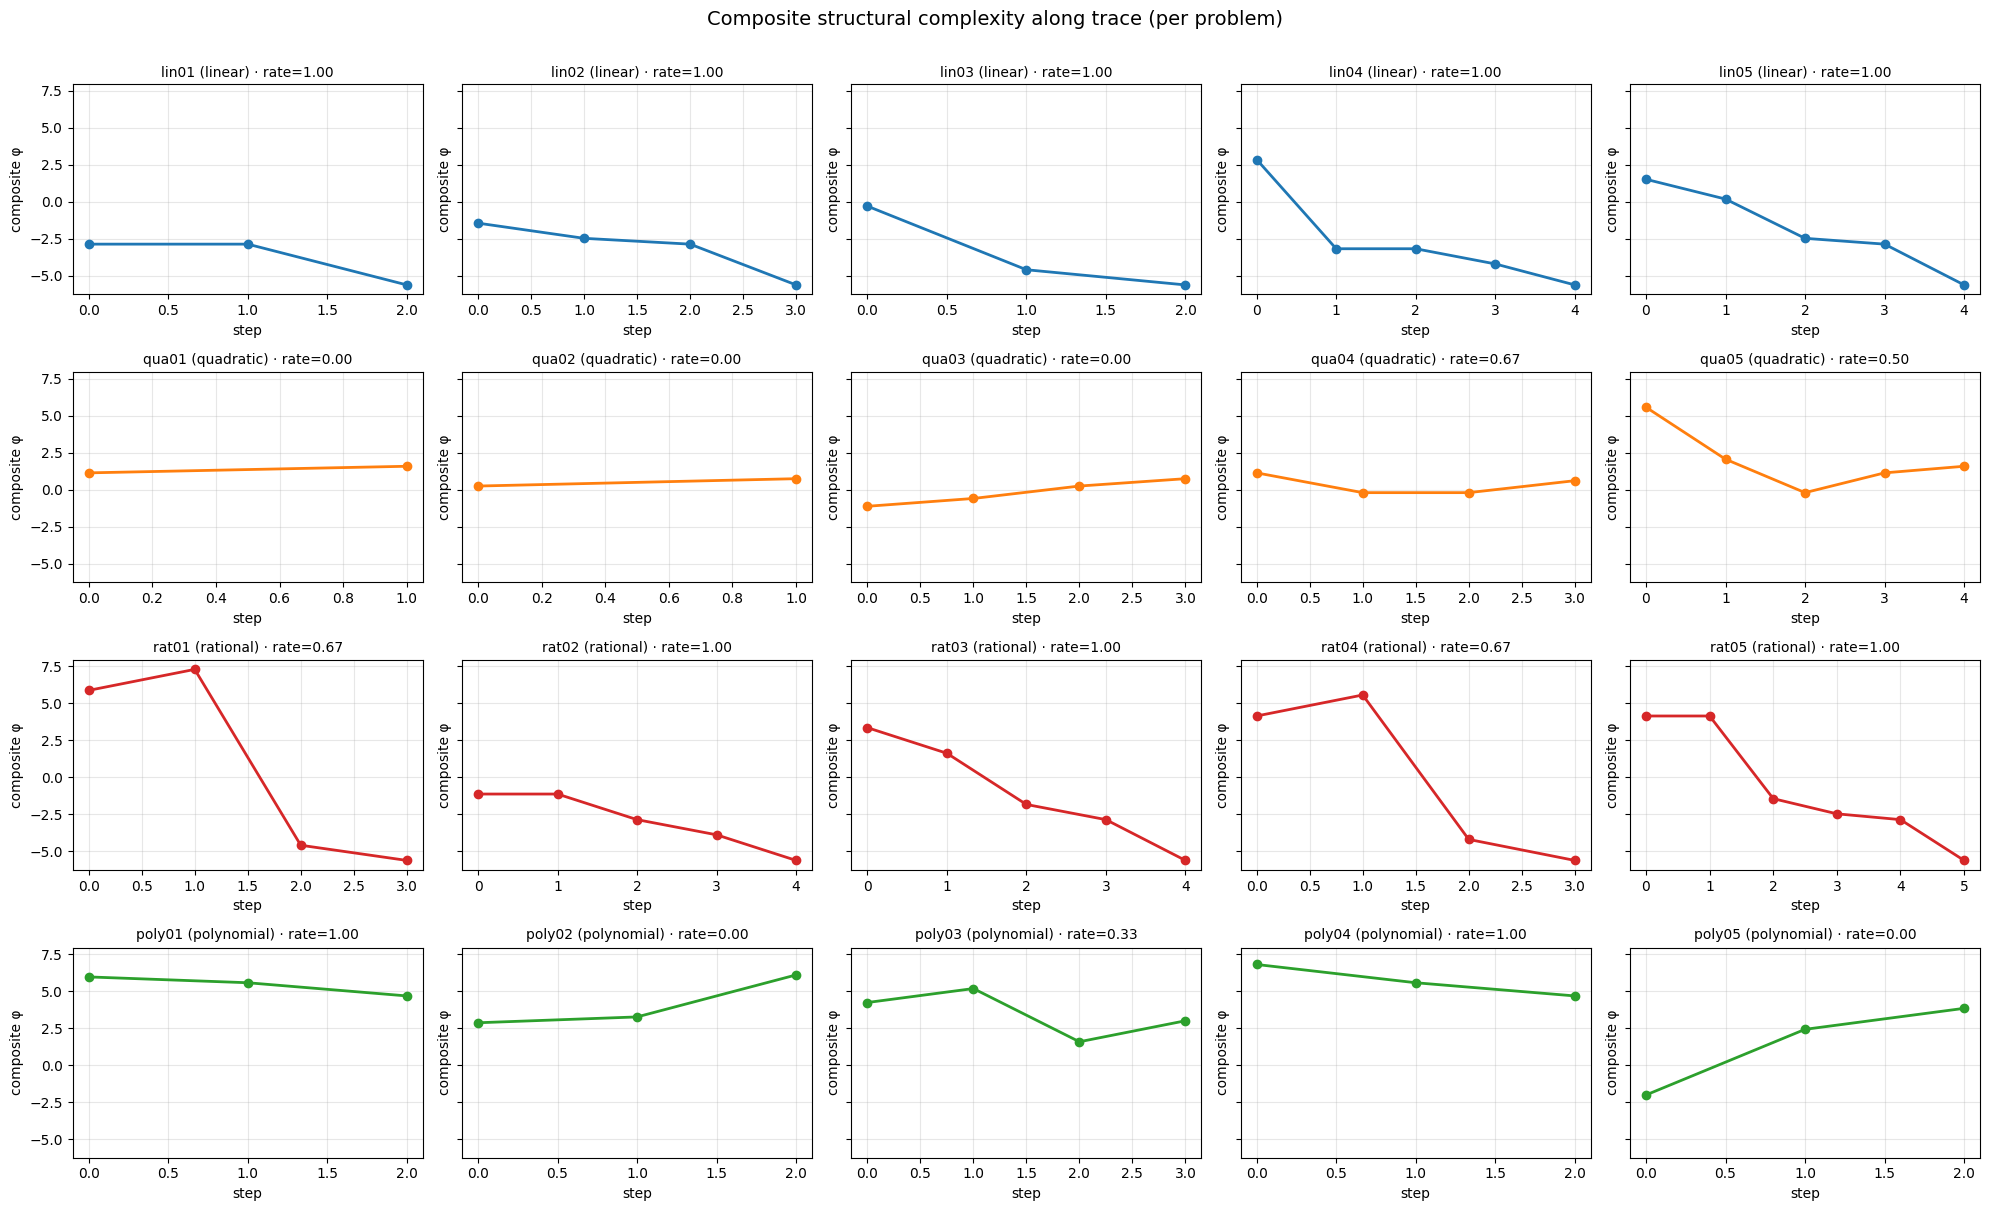

In [3]:
category_color = {
    'linear': '#1f77b4',
    'quadratic': '#ff7f0e',
    'rational': '#d62728',
    'polynomial': '#2ca02c',
}

problems = traces.problem_id.unique()
n = len(problems)
ncols = 5
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3 * nrows), sharey=True)
axes = axes.flatten()

for ax, pid in zip(axes, problems):
    sub = traces[traces.problem_id == pid].sort_values('step_idx')
    cat = sub.category.iloc[0]
    ax.plot(sub.step_idx, sub.composite, marker='o', color=category_color[cat], lw=2)
    rate = mono[mono.problem_id == pid].composite_rate.iloc[0]
    ax.set_title(f'{pid} ({cat}) · rate={rate:.2f}', fontsize=10)
    ax.set_xlabel('step')
    ax.set_ylabel('composite φ')
    ax.grid(True, alpha=0.3)

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('Composite structural complexity along trace (per problem)', fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig(OUTPUTS / 'fig_trajectories.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Per-category aggregated rates

Rates by category. Linear should be near 1.0. Quadratic and polynomial may show §2.1 pattern (expand-then-collapse). Rational mixed.

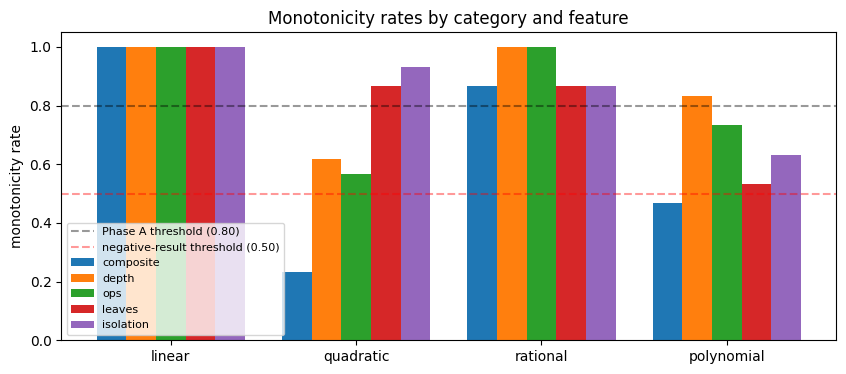

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))

cats = ['linear', 'quadratic', 'rational', 'polynomial']
feature_cols = ['composite_rate', 'depth_rate', 'ops_rate', 'leaves_rate', 'isolation_rate']
feature_labels = ['composite', 'depth', 'ops', 'leaves', 'isolation']

x = np.arange(len(cats))
width = 0.16
for i, (col, label) in enumerate(zip(feature_cols, feature_labels)):
    means = [mono[mono.category == c][col].mean() for c in cats]
    ax.bar(x + i * width, means, width, label=label)

ax.set_xticks(x + 2 * width)
ax.set_xticklabels(cats)
ax.set_ylabel('monotonicity rate')
ax.axhline(0.80, color='k', linestyle='--', alpha=0.4, label='Phase A threshold (0.80)')
ax.axhline(0.50, color='r', linestyle='--', alpha=0.4, label='negative-result threshold (0.50)')
ax.legend(loc='lower left', fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_title('Monotonicity rates by category and feature')
plt.savefig(OUTPUTS / 'fig_per_category.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Δφ histogram (step-level deltas)

Distribution of `φ(s_{t+1}) - φ(s_t)` across all transitions. Negative = decrease (good). Right-skew = many decreases. Bimodal would suggest two regimes.

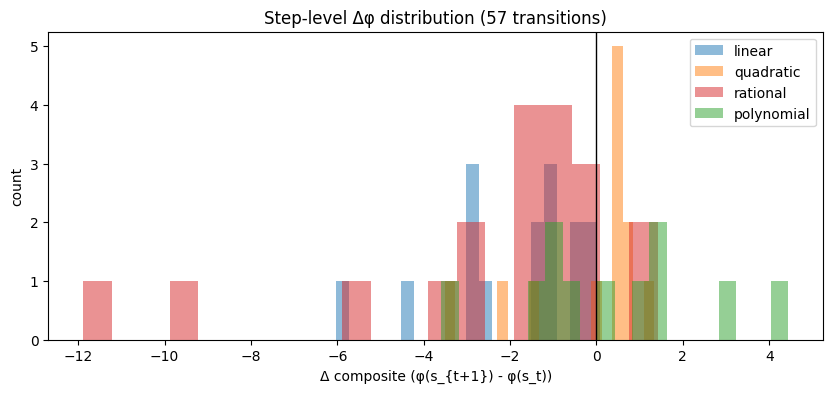


Total transitions: 57
  Δ < 0 (decrease):  36 (63.2%)
  Δ = 0 (plateau):   5 (8.8%)
  Δ > 0 (increase):  16 (28.1%)


In [5]:
deltas = []
for pid in problems:
    sub = traces[traces.problem_id == pid].sort_values('step_idx')
    vals = sub.composite.values
    for i in range(len(vals) - 1):
        deltas.append({'problem_id': pid, 'category': sub.category.iloc[0],
                       'delta': vals[i + 1] - vals[i]})
deltas = pd.DataFrame(deltas)

fig, ax = plt.subplots(figsize=(10, 4))
for cat in cats:
    sub = deltas[deltas.category == cat]
    ax.hist(sub.delta, bins=20, alpha=0.5, label=cat, color=category_color[cat])

ax.axvline(0, color='k', linewidth=1)
ax.set_xlabel('Δ composite (φ(s_{t+1}) - φ(s_t))')
ax.set_ylabel('count')
ax.set_title(f'Step-level Δφ distribution ({len(deltas)} transitions)')
ax.legend()
plt.savefig(OUTPUTS / 'fig_delta_histogram.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nTotal transitions: {len(deltas)}')
print(f'  Δ < 0 (decrease):  {(deltas.delta < 0).sum()} ({(deltas.delta < 0).mean()*100:.1f}%)')
print(f'  Δ = 0 (plateau):   {(deltas.delta == 0).sum()} ({(deltas.delta == 0).mean()*100:.1f}%)')
print(f'  Δ > 0 (increase):  {(deltas.delta > 0).sum()} ({(deltas.delta > 0).mean()*100:.1f}%)')

## 5. AC-variant fragility heatmap

Each row = problem. Columns = original / 3 variants. Color = monotonicity rate.
Identical colors across a row = AC-stable. Color shifts = parser-dependent fragility.

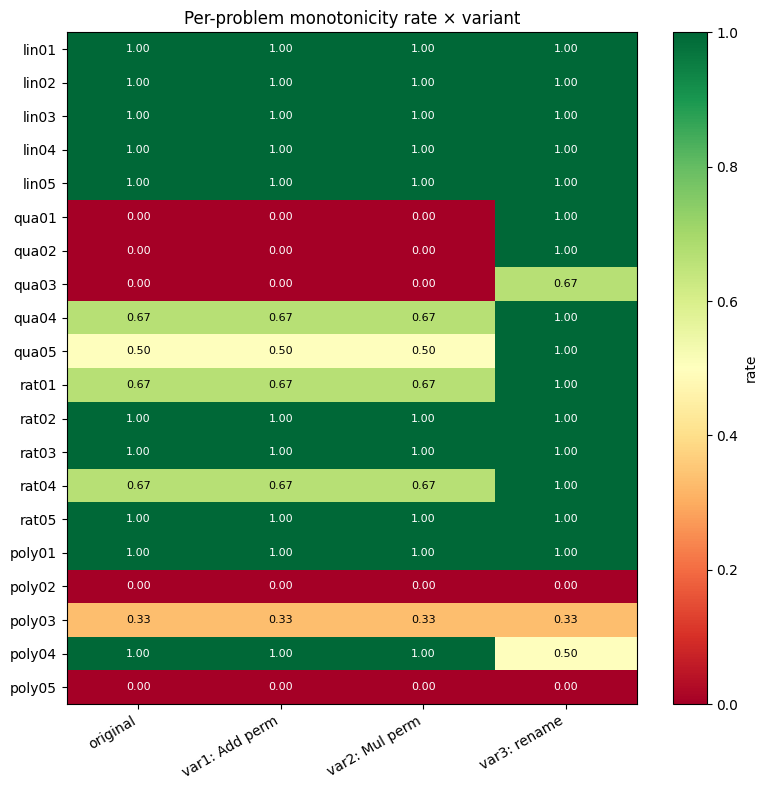


Problems with σ > 0.10 (parser-dependent fragility): 8/20
problem_id  original_rate  var3_rename_rate    sigma
     qua01       0.000000          1.000000 0.500000
     qua02       0.000000          1.000000 0.500000
     qua03       0.000000          0.666667 0.333333
     qua05       0.500000          1.000000 0.250000
    poly04       1.000000          0.500000 0.250000
     qua04       0.666667          1.000000 0.166667
     rat01       0.666667          1.000000 0.166667
     rat04       0.666667          1.000000 0.166667


In [6]:
heat = variants[['problem_id', 'original_rate', 'var1_addperm_rate',
                 'var2_mulperm_rate', 'var3_rename_rate']].set_index('problem_id')

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(heat.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(['original', 'var1: Add perm', 'var2: Mul perm', 'var3: rename'], rotation=30, ha='right')
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_title('Per-problem monotonicity rate × variant')
plt.colorbar(im, ax=ax, label='rate')

for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        v = heat.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(v - 0.5) > 0.3 else 'black')

plt.tight_layout()
plt.savefig(OUTPUTS / 'fig_variant_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

high_sigma = variants[variants.sigma > 0.10].sort_values('sigma', ascending=False)
print(f'\nProblems with σ > 0.10 (parser-dependent fragility): {len(high_sigma)}/20')
print(high_sigma[['problem_id', 'original_rate', 'var3_rename_rate', 'sigma']].to_string(index=False))

## 6. Drill-down: §2.1 motivating cases

Inspect rat01 (the §2.1 example) and qua03 (textbook expand-then-factor) — should show structure rising then falling.

In [7]:
for pid in ['rat01', 'qua03', 'qua04', 'qua05']:
    sub = traces[traces.problem_id == pid].sort_values('step_idx')
    print(f'\n{pid}:')
    for _, r in sub.iterrows():
        print(f'  step {int(r.step_idx)}: depth={int(r.depth)} ops={int(r.ops)} '
              f'leaves={int(r.leaves)} isol={int(r.isolation)} '
              f'composite={r.composite:+.3f}  | {r.expr}')


rat01:
  step 0: depth=6 ops=8 leaves=9 isol=2 composite=+5.873  | (x**2 - 1*1)/(x - 1*1) = 3
  step 1: depth=6 ops=8 leaves=10 isol=3 composite=+7.292  | (x + 1)*(x - 1*1)/(x - 1*1) = 3
  step 2: depth=2 ops=1 leaves=2 isol=1 composite=-4.590  | x + 1 = 3
  step 3: depth=2 ops=1 leaves=2 isol=0 composite=-5.615  | x = 2

qua03:
  step 0: depth=4 ops=3 leaves=4 isol=1 composite=-1.130  | (x + 1)**2 = 4
  step 1: depth=3 ops=3 leaves=5 isol=2 composite=-0.602  | x**2 + 2*x + 1 = 4
  step 2: depth=3 ops=4 leaves=6 isol=2 composite=+0.238  | x**2 + 2*x - 1*3 = 0
  step 3: depth=4 ops=4 leaves=5 isol=2 composite=+0.735  | (x + 3)*(x - 1*1) = 0

qua04:
  step 0: depth=4 ops=4 leaves=6 isol=2 composite=+1.128  | x**2 - 4*x + 1 = 0
  step 1: depth=3 ops=3 leaves=6 isol=2 composite=-0.208  | x**2 - 4*x = -1
  step 2: depth=3 ops=3 leaves=6 isol=2 composite=-0.208  | x**2 - 4*x + 4 = 3
  step 3: depth=5 ops=4 leaves=5 isol=1 composite=+0.600  | (x - 1*2)**2 = 3

qua05:
  step 0: depth=5 ops=7 

## Visual findings (manual annotations)

(After running cells above, edit this cell with your observations to feed back into the report.)

- **Linear (lin01-05):** all rates 1.0 — purely monotone, as expected for trivial textbook arithmetic.
- **Quadratic (qua01-05):** lowest category. qua03/qua04/qua05 show the §2.1 expand-then-factor pattern explicitly. qua01/qua02 are 1-step factor problems and have rate 0.0 because the single transition adds factoring structure.
- **Rational (rat01-05):** mixed. rat01 (the §2.1 motivating example) is non-monotone at the FACTOR step (numerator factoring inflates ops/leaves); rat02-rat05 (clear-fractions) are mostly monotone.
- **Polynomial (poly01-05):** lowest after quadratic. poly02/poly05 (factoring quartic) introduce many factors at once → composite rises sharply.
- **AC fragility:** the variable rename variant (var3) most dramatically changes monotonicity, especially for short (1-step) traces where a single composite-flip swings the rate from 0 to 1.

These visual findings reinforce the H = 0.64 headline: the composite is non-monotone particularly through factoring/expansion steps that *appear* productive but *increase* structural complexity. This is exactly the §2.1 thesis.